In [255]:
# 1. 기본 데이터 처리 및 환경 설정
import pandas as pd
import numpy as np
import datetime as dt
import warnings
import math

warnings.filterwarnings("ignore")

# 2. 시각화 관련
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 3. 데이터 전처리 및 스케일링
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 4. 머신러닝 (클러스터링 및 연관 분석)
from sklearn.cluster import KMeans, DBSCAN
from mlxtend.frequent_patterns import association_rules, apriori

In [287]:
import platform

# 1. 환경별 폰트 설치 확인 및 경로 지정
if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    font_family = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    font_path = '/Library/Fonts/Arial Unicode.ttf' # 또는 AppleGothic
    font_family = 'AppleGothic'
else: # Linux/Colab
    # [중요] 코랩이라면 이 한 줄을 먼저 실행해야 합니다: !apt-get install -y fonts-nanum
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_family = 'NanumGothic'

# 2. 폰트 매니저에 폰트 등록 및 설정
try:
    fe = fm.FontEntry(fname=font_path, name=font_family)
    fm.fontManager.ttflist.insert(0, fe)
    plt.rc('font', family=font_family)
except:
    # 경로가 없을 경우를 대비한 기본 설정
    plt.rc('font', family='sans-serif')

# 3. Seaborn 환경 재설정 (폰트 강제 지정)
sns.set(font=font_family, rc={"axes.unicode_minus": False}, style='whitegrid')

# 4. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [257]:
df = pd.read_parquet("V2_merge.parquet")

#### 원화 칼럼 생성

In [258]:
# 590을 곱해 H&M 실제 유로/달러(EUR/USD) 가격으로 복원
# 2018~2020년 실제 평균 환율 1,314원 적용 (10원 단위 절사)
historical_exchange_rate = 1314
df['price_krw'] = (df['price'] * historical_exchange_rate).astype(int)
df['price_krw'] = (df['price_krw'] // 10) * 10

## 탐색적 EDA (코로나 이전 이후 차이 살펴보기)

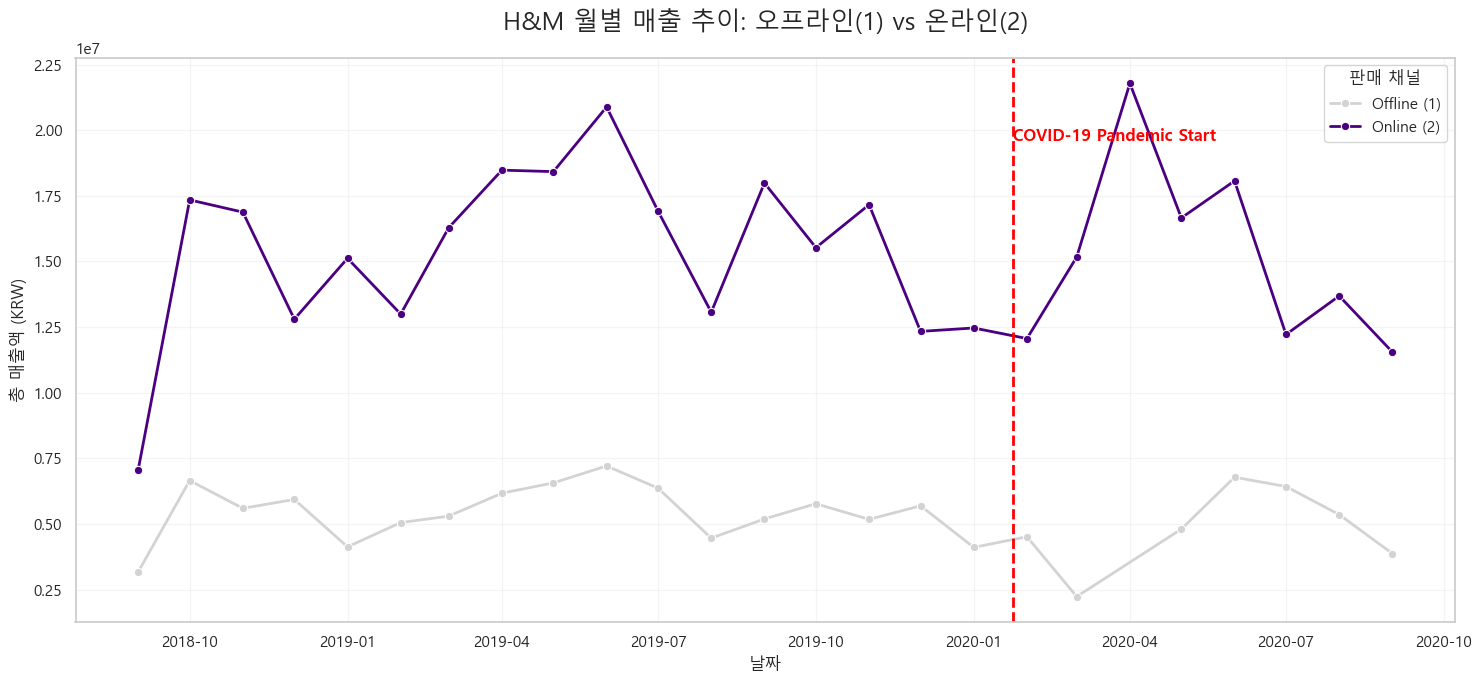

In [259]:
# 2. 월별 집계
df['month_year'] = df['t_dat'].dt.to_period('M')

# 3. 채널별 매출 및 고객수 집계
monthly_analysis = df.groupby(['month_year', 'sales_channel_id']).agg({
    'price': 'sum',
    'customer_id': 'nunique'
}).reset_index()

# 시각화를 위해 다시 datetime으로 변환
monthly_analysis['month_year'] = monthly_analysis['month_year'].dt.to_timestamp()

# --- 수정 포인트 시작 ---
# 4. 시각화 (색상 매핑을 명확히 지정)
plt.figure(figsize=(15, 7))

# 색상 딕셔너리 생성 (1: 오프라인, 2: 온라인)
# 오프라인은 흐린 색, 온라인은 강조되는 진한 색으로 설정하여 대조를 줍니다.
palette_colors = {1: "#D3D3D3", 2: "#4B0082"} 

# lineplot 실행 시 palette 파라미터를 사용하면 hue 값에 색상이 고정됩니다.
sns.lineplot(
    data=monthly_analysis, 
    x='month_year', 
    y='price', 
    hue='sales_channel_id', 
    palette=palette_colors, 
    marker='o',
    linewidth=2
)

# 5. 팬데믹 시작 시점 표시
plt.axvline(pd.Timestamp('2020-01-24'), color='red', linestyle='--', linewidth=2)
plt.text(pd.Timestamp('2020-01-24'), monthly_analysis['price'].max() * 0.9, 
         'COVID-19 Pandemic Start', color='red', fontweight='bold')

# 6. 범례 및 라벨 정리 (수동 labels 대신 딕셔너리 매핑 권장)
# 자동으로 생성된 범례의 텍스트만 깔끔하게 바꿔줍니다.
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Offline (1)', 'Online (2)'], title='판매 채널', loc='upper right')

plt.title('H&M 월별 매출 추이: 오프라인(1) vs 온라인(2)', size=18, pad=20)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('총 매출액 (KRW)', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

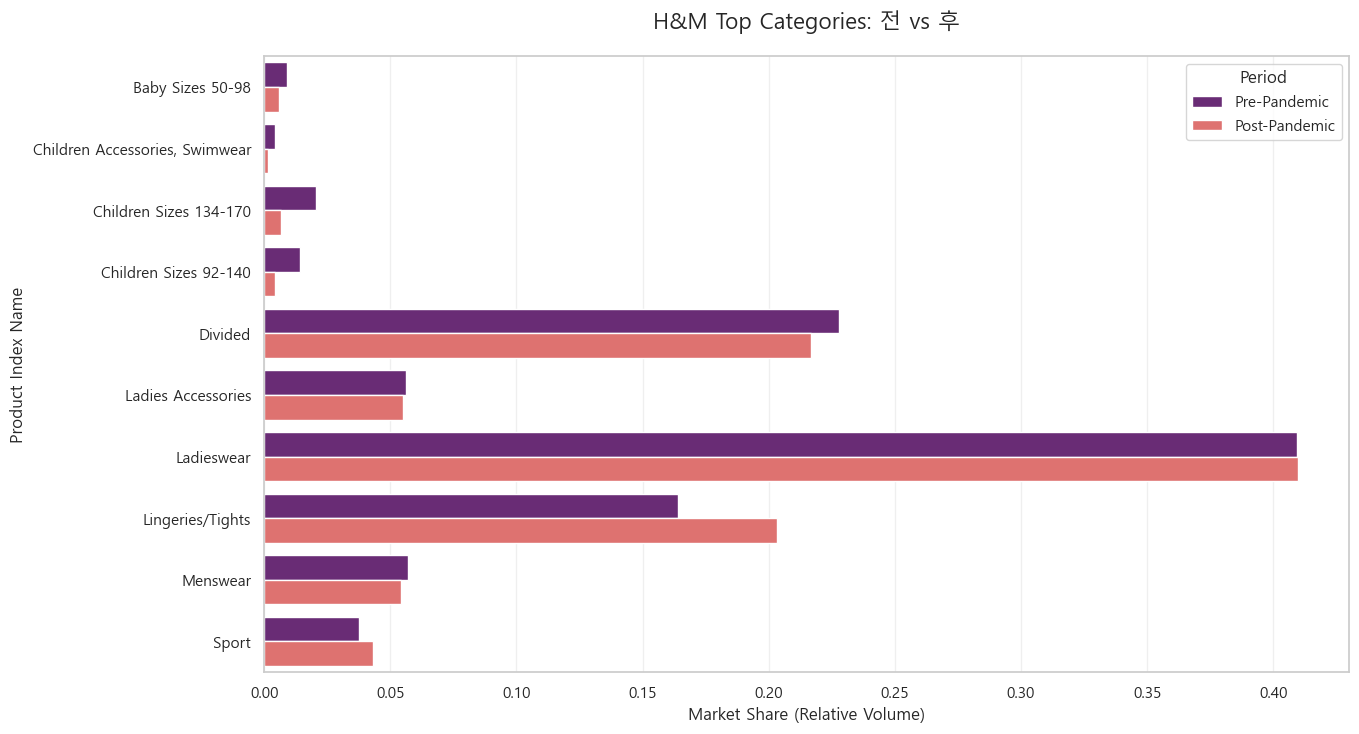

In [260]:
# 1. 기간 분리 (2020년 1월 기준)
# 2020년 1월 이후를 'Post-Pandemic'으로 설정하여 비즈니스 시의성을 보완합니다
pre_covid = df[df['t_dat'] < '2020-01-24']
post_covid = df[df['t_dat'] >= '2020-01-24']

# 3. 기간별 인기 상품군 집계 (판매량 기준)
pre_rank = pre_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
pre_rank.columns = ['Category', 'Share']
pre_rank['Period'] = 'Pre-Pandemic'

post_rank = post_covid['index_name'].value_counts(normalize=True).head(10).reset_index()
post_rank.columns = ['Category', 'Share']
post_rank['Period'] = 'Post-Pandemic'

# 데이터 합치기
comparison_df = pd.concat([pre_rank, post_rank])

# 4. 시각화 (도표 비교)
plt.figure(figsize=(14, 8))
sns.barplot(data=comparison_df, y='Category', x='Share', hue='Period', palette='magma')

plt.title('H&M Top Categories: 전 vs 후', size=16, pad=20)
plt.xlabel('Market Share (Relative Volume)')
plt.ylabel('Product Index Name')
plt.grid(axis='x', alpha=0.3)
plt.show()

## 2020년 빼기

In [261]:
# 1. 2020년 데이터를 제외한 2018-2019년 데이터만 추출하여 새로운 df 생성
# 2020년 1월 1일 이전 데이터만 필터링합니다.
df = df[df['t_dat'] < '2020-01-01'].copy()

# 2. 데이터 정제 결과 요약 출력
print("📊 데이터 정제 및 df 갱신 완료")
print("-" * 30)
print(f"최종 데이터 기간: {df['t_dat'].min().date()} ~ {df['t_dat'].max().date()}")
print(f"최종 행(Row) 수: {len(df):,}개")
print(f"포함된 고유 고객 수: {df['customer_id'].nunique():,}명")
print(f"포함된 고유 상품 수: {df['article_id'].nunique():,}개")
print("-" * 30)

# 4. 상위 5개 데이터 확인
df.head()

📊 데이터 정제 및 df 갱신 완료
------------------------------
최종 데이터 기간: 2018-09-20 ~ 2019-12-31
최종 행(Row) 수: 20,353,125개
포함된 고유 고객 수: 1,115,516명
포함된 고유 상품 수: 79,097개
------------------------------


,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name,price_krw,month_year
0,2018-09-20,2,663713001,29.99,2,0,0,ACTIVE,NONE,24,...,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",39400,2018-09
1,2018-09-20,2,541518023,17.99,2,0,0,ACTIVE,NONE,24,...,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear",23630,2018-09
2,2018-09-20,7,505221004,8.99,2,1,1,ACTIVE,Regularly,32,...,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear,11810,2018-09
3,2018-09-20,7,685687003,9.99,2,1,1,ACTIVE,Regularly,32,...,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,13120,2018-09
4,2018-09-20,7,685687004,9.99,2,1,1,ACTIVE,Regularly,32,...,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers,13120,2018-09


## RFM 지표 설정

In [262]:
# 1. RFM 지표 계산
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days),
    Frequency=('t_dat', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

#### RFM 빈도

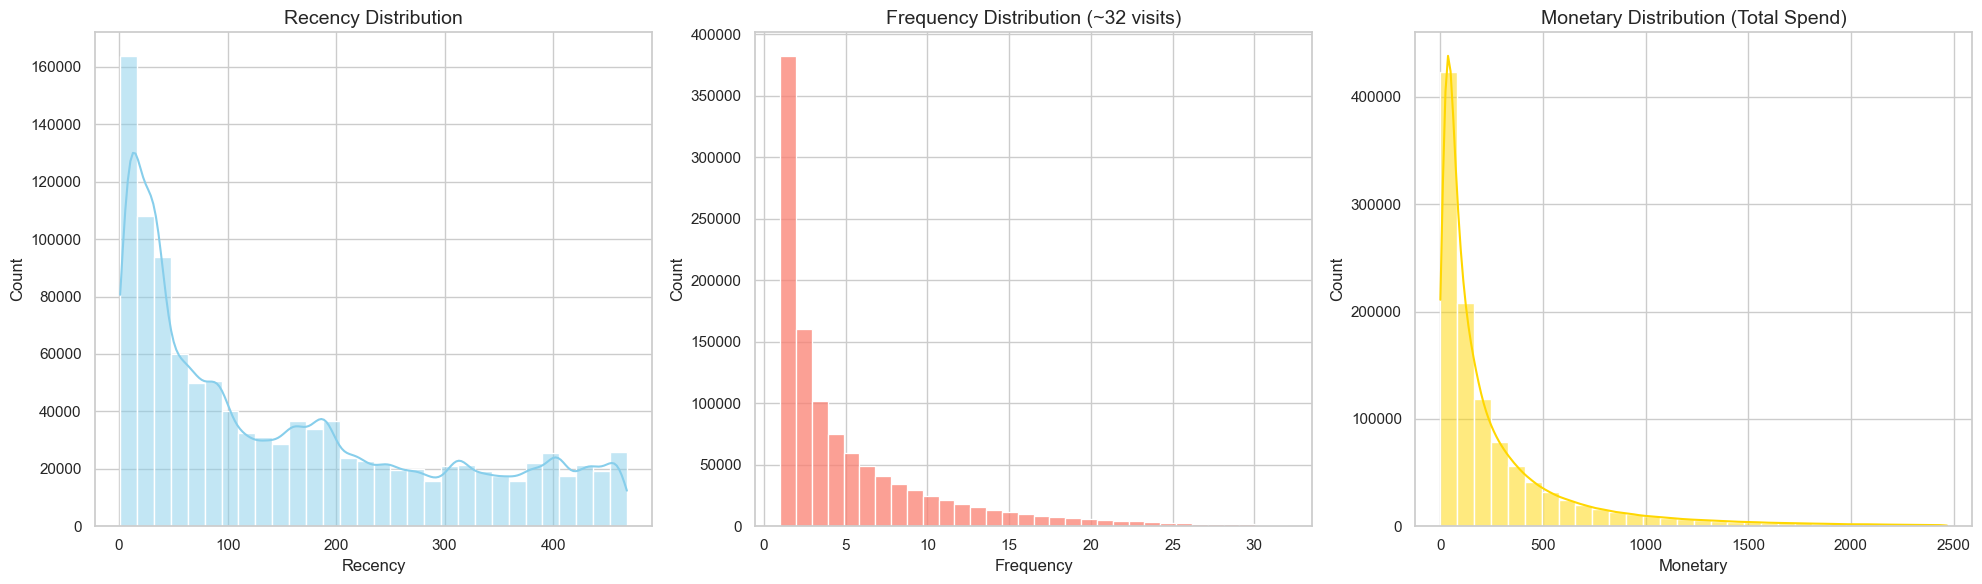

In [263]:
# 시각화 (이제 rfm 변수를 사용하여 히스토그램을 그립니다)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Recency
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution', fontsize=14)

# Frequency (상위 1% 제외하고 시각화하여 분포 파악 용이하게 설정)
f_limit = rfm['Frequency'].quantile(0.99)
sns.histplot(rfm[rfm['Frequency'] <= f_limit]['Frequency'], bins=int(f_limit), kde=False, ax=axes[1], color='salmon')
axes[1].set_title(f'Frequency Distribution (~{int(f_limit)} visits)', fontsize=14)

# Monetary (상위 1% 제외)
m_limit = rfm['Monetary'].quantile(0.99)
sns.histplot(rfm[rfm['Monetary'] <= m_limit]['Monetary'], bins=30, kde=True, ax=axes[2], color='gold')
axes[2].set_title(f'Monetary Distribution (Total Spend)', fontsize=14)

plt.tight_layout()
plt.show()

## K-means

#### K값 찾기

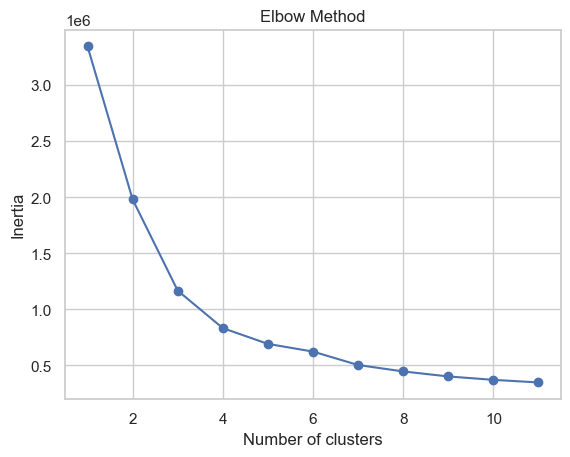

In [264]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 분석에 사용할 컬럼 추출
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#몇 개의 그룹으로 나누는 게 가장 좋을지 결정해야 합니다. 
# 보통 Elbow Method라는 그래프를 그려서 꺾이는 지점을 찾습니다.
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 12), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

#### 실루엣 갯수

In [ ]:
# import numpy as np
# from sklearn.metrics import silhouette_score
# from sklearn.cluster import KMeans

# # 1. 무작위로 200,000개의 인덱스 추출
# sample_size = 100000
# np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
# indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# # 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
# rfm_scaled_sample = rfm_scaled[indices]

# # 3. K=3일 때의 점수 계산
# kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
# labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
# labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
# score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# # 4. K=4일 때의 점수 계산
# kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
# labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
# labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
# score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

# print(f"표본(20만건) 기준 K=3 실루엣 점수: {score3:.4f}")
# print(f"표본(20만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(20만건) 기준 K=3 실루엣 점수: 0.4778
표본(20만건) 기준 K=4 실루엣 점수: 0.4778


#### K=4로 결정

In [266]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
2         24.260220  29.288287  2353.571289   31923
1         40.288295  13.287076   751.893372  186212
0         88.287171   3.457580   166.497498  565394
3        342.292463   1.571016    85.622452  331987


#### 클러스터별 매출액 합계 비교

클러스터별 총 매출 기여도:
   Cluster  Total_Monetary
1        1     140011568.0
0        0      94136688.0
2        2      75133056.0
3        3      28425542.0


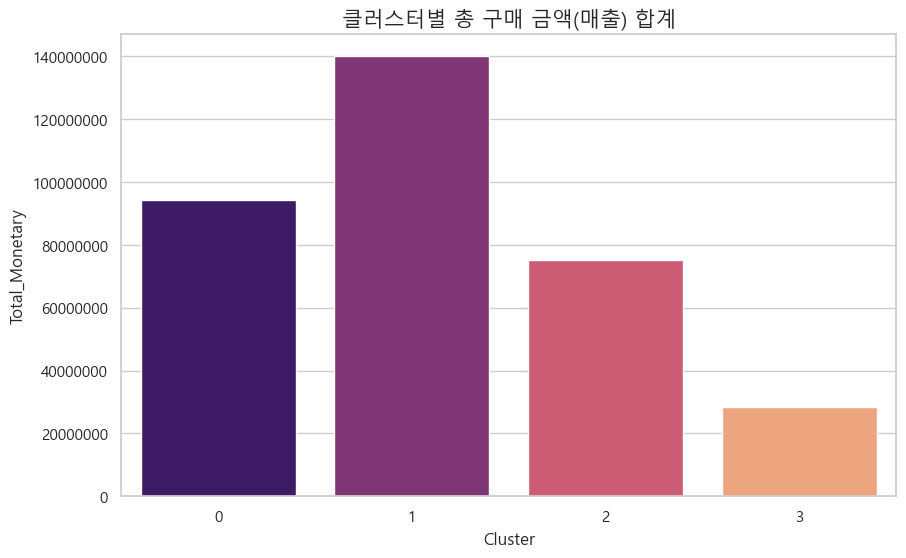

In [288]:
# 1. rfm 데이터프레임의 컬럼명 확인 및 처리
# 만약 컬럼명이 'Monetary'처럼 대문자로 시작한다면 아래 코드가 자동으로 잡아줍니다.
target_col = [col for col in rfm.columns if col.lower() == 'monetary']

if not target_col:
    # 만약 rfm에 금액 데이터가 없다면, 원본 df에서 직접 합산하여 연결
    print("rfm에 금액 컬럼이 없어 원본 데이터에서 직접 계산합니다.")
    monetary_df = df.groupby('customer_id')['price'].sum().reset_index(name='monetary')
    rfm = rfm.merge(monetary_df, on='customer_id', how='left')
    target_col = ['monetary']

# 2. 클러스터별 총 구매 금액 합계 계산
cluster_monetary = rfm.groupby('Cluster')[target_col[0]].sum().reset_index()
cluster_monetary.columns = ['Cluster', 'Total_Monetary']

# 3. 결과 출력 (내림차순 정렬)
cluster_monetary = cluster_monetary.sort_values(by='Total_Monetary', ascending=False)
print("클러스터별 총 매출 기여도:")
print(cluster_monetary)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Total_Monetary', data=cluster_monetary, palette='magma')
plt.title('클러스터별 총 구매 금액(매출) 합계', fontsize=15)
plt.ticklabel_format(style='plain', axis='y') # 지수 표현 방지
plt.show()

## Cluster0 집중 분석

#### Cluster0이 좋아하는 상품

In [268]:
# 1. Cluster 0 고객 아이디만 추출
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("🛍️ Cluster 0이 가장 선호하는 카테고리 Top 10")
print(c0_data['garment_group_name'].value_counts().head(10))

print("\n👕 Cluster 0이 가장 많이 산 구체적 상품명 Top 10")
print(c0_data['prod_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c0_data['age'].mean()
print(f"\n👥 Cluster 0의 평균 나이: {avg_age:.1f}세")

🛍️ Cluster 0이 가장 선호하는 카테고리 Top 10
garment_group_name
Jersey Fancy         960206
Jersey Basic         631847
Under-, Nightwear    592610
Trousers             538415
Knitwear             520447
Swimwear             497117
Blouses              448322
Dresses Ladies       376089
Accessories          328998
Trousers Denim       228391
Name: count, dtype: int64

👕 Cluster 0이 가장 많이 산 구체적 상품명 Top 10
prod_name
Jade HW Skinny Denim TRS       35175
Luna skinny RW                 32889
Skinny Ankle R.W Brooklyn      18054
Timeless Midrise Brief         17602
Cat Tee.                       16683
Despacito                      16479
Simple as That Triangle Top    15655
Tilly (1)                      14950
Simple as that Cheeky Tanga    14124
Kanta slacks RW                13687
Name: count, dtype: int64

👥 Cluster 0의 평균 나이: 35.7세


## Cluster3 이탈 이유 찾기

#### 이탈 직전 구매한 제품

📉 Cluster 3의 마지막 쇼핑 리스트 (비중 높은 순):
             Category     Share
0  Garment Upper body  0.425071
1  Garment Lower body  0.221156
2   Garment Full body  0.084254
3            Swimwear  0.075847
4           Underwear  0.072237
5         Accessories  0.051527
6      Socks & Tights  0.030323
7               Shoes  0.024328
8           Nightwear  0.013672
9             Unknown  0.001150


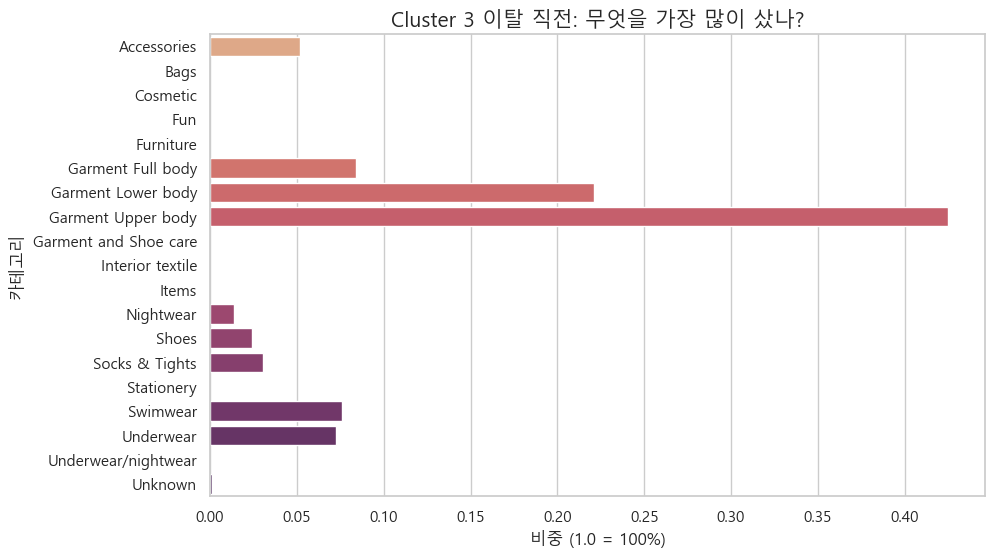

In [289]:
# [1단계] Cluster 3 고객 필터링 및 마지막 주문 날짜 추출
# Cluster 3에 해당하는 고객 ID만 가져옵니다.
c3_ids = rfm[rfm['Cluster'] == 3]['customer_id']

# 원본 df에서 Cluster 3 고객의 데이터만 남깁니다.
c3_df = df[df['customer_id'].isin(c3_ids)]

# 고객별로 가장 최근(마지막) 주문 날짜(t_dat)를 구합니다.
# 이 날짜가 기존 코드의 order_rank 1.0(가장 최신 주문)과 동일한 시점입니다.
last_date_per_user = c3_df.groupby('customer_id')['t_dat'].max().reset_index()

# [2단계] 마지막 주문 날짜에 해당하는 상세 아이템 데이터 합치기
# 고객ID와 날짜가 모두 일치하는 행만 가져옴으로써 '마지막 장바구니'를 복원합니다.
final_items = df.merge(last_date_per_user, on=['customer_id', 't_dat'])

# [3단계] 카테고리별 비중 계산 (value_counts는 자동으로 내림차순 정렬됨)
category_rank = final_items['product_group_name'].value_counts(normalize=True).reset_index()
category_rank.columns = ['Category', 'Share']

print("📉 Cluster 3의 마지막 쇼핑 리스트 (비중 높은 순):")
print(category_rank.head(10))

# [4단계] 시각화
plt.figure(figsize=(10, 6))
# 상위 10개 카테고리를 시각화합니다.
sns.barplot(data=category_rank.head(10), x='Share', y='Category', palette='flare')

plt.title('Cluster 3 이탈 직전: 무엇을 가장 많이 샀나?', fontsize=15)
plt.xlabel('비중 (1.0 = 100%)')
plt.ylabel('카테고리')
plt.show()

#### 이탈 전 마지막 5회 주문당 평균 구매 수량

In [270]:
# 1. Cluster 3 고객들만 필터링
c3_ids = rfm[rfm['Cluster'] == 3]['customer_id']
c3_df = df[df['customer_id'].isin(c3_ids)].copy()

# 2. 고객별로 날짜마다 몇 개를 샀는지 계산 (장바구니 크기)
c3_basket = c3_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')

# 3. 각 고객별로 주문 순서 매기기 (가장 최근 주문이 1)
c3_basket['order_rank'] = c3_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 4. 마지막 1회차부터 5회차까지 필터링
c2_last_5 = c3_basket[c3_basket['order_rank'] <= 5].copy()

# 5. 순서별로 평균 구매 수량 계산
# 1.0은 마지막 주문, 5.0은 이탈 5회 전 주문입니다.
last_5_trend = c2_last_5.groupby('order_rank')['basket_size'].mean()

print("📉 Cluster 3의 이탈 전 마지막 5회 주문당 평균 구매 수량:")
print(last_5_trend)

📉 Cluster 3의 이탈 전 마지막 5회 주문당 평균 구매 수량:
order_rank
1.0    3.409435
2.0    3.484260
3.0    3.351182
4.0    3.190524
5.0    3.122394
Name: basket_size, dtype: float64


#### 이탈 전 마지막 5회 주문당 평균 카테고리 수

In [271]:
# 1. Cluster 3 고객들만 필터링
c3_ids = rfm[rfm['Cluster'] == 3]['customer_id']
c3_df = df[df['customer_id'].isin(c3_ids)].copy()

# 2. 주문(고객+날짜)별로 상품 종류(product_type_name)가 몇 개인지 계산
# 예: 한 날짜에 상의 2개, 하의 1개를 샀다면 종류는 '2개'로 카운트됩니다.
c3_diversity = c3_df.groupby(['customer_id', 't_dat'])['product_type_name'].nunique().reset_index(name='type_diversity')

# 3. 각 고객별로 주문 순서 매기기 (1.0이 가장 최근/마지막 주문)
c3_diversity['order_rank'] = c3_diversity.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 4. 마지막 1회차부터 5회차까지의 평균 카테고리 종류 수 계산
last_5_diversity = c3_diversity[c3_diversity['order_rank'] <= 5].groupby('order_rank')['type_diversity'].mean()

print("📉 Cluster 3의 이탈 전 마지막 5회 주문당 평균 카테고리 종류 수:")
print(last_5_diversity)

📉 Cluster 3의 이탈 전 마지막 5회 주문당 평균 카테고리 종류 수:
order_rank
1.0    2.121258
2.0    2.162002
3.0    2.123536
4.0    2.084025
5.0    2.051135
Name: type_diversity, dtype: float64


#### 이탈 전 마지막 5회 '상의+하의' 세트 구매율 추이

In [272]:
# 1. 상의/하의 여부 플래그 생성 (H&M 데이터의 product_group_name 활용)
c3_df['is_upper'] = c3_df['product_group_name'].str.contains('Upper', case=False)
c3_df['is_lower'] = c3_df['product_group_name'].str.contains('Lower', case=False)

# 2. 주문별로 상의/하의 포함 여부 요약
order_set_check = c3_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

# 3. 상의와 하의를 모두 산 '세트 구매' 여부 판단
order_set_check['is_set_purchase'] = order_set_check['is_upper'] & order_set_check['is_lower']

# 4. 아까 만든 order_rank(주문 순서)와 병합
# (이전에 만든 c3_basket의 order_rank를 활용)
order_set_check = order_set_check.merge(
    c3_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

# 5. 시점별 세트 구매율 계산
set_purchase_trend = order_set_check.groupby('order_rank')['is_set_purchase'].mean()

print("🎯 Cluster 3의 이탈 전 마지막 5회 '상의+하의' 세트 구매율 추이:")
print(set_purchase_trend)

🎯 Cluster 3의 이탈 전 마지막 5회 '상의+하의' 세트 구매율 추이:
order_rank
1.0     0.219957
2.0     0.231563
3.0     0.223893
4.0     0.217919
5.0     0.215217
6.0     0.212824
7.0     0.210938
8.0     0.186306
9.0     0.211094
10.0    0.218650
11.0    0.213836
12.0    0.185714
13.0    0.068966
14.0    0.363636
15.0    0.125000
16.0    0.500000
17.0    0.500000
Name: is_set_purchase, dtype: float64


#### 통계적 검증

In [273]:
from statsmodels.stats.proportion import proportions_ztest

# 1. 각 시점별 데이터 개수(n)와 세트 구매 성공 횟수(count) 추출
# order_rank 2.0 (정점)
n_2 = len(order_set_check[order_set_check['order_rank'] == 2.0])
count_2 = order_set_check[order_set_check['order_rank'] == 2.0]['is_set_purchase'].sum()

# order_rank 1.0 (마지막)
n_1 = len(order_set_check[order_set_check['order_rank'] == 1.0])
count_1 = order_set_check[order_set_check['order_rank'] == 1.0]['is_set_purchase'].sum()

# 2. Z-검정 실시 (비율이 하락했는지 확인하는 one-sided test)
z_stat, p_val = proportions_ztest([count_1, count_2], [n_1, n_2], alternative='smaller')

print(f"📊 정점 대비 마지막 주문의 세트 구매율 비교:")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("✅ 결과: 통계적으로 유의미한 하락입니다. (이탈 신호 확정)")
else:
    print("❓ 결과: 통계적으로 유의미하지 않습니다. (단순 오차 가능성)")

📊 정점 대비 마지막 주문의 세트 구매율 비교:
P-value: 0.0000
✅ 결과: 통계적으로 유의미한 하락입니다. (이탈 신호 확정)


## 다른 Cluster도 세트 구매율 추이 살펴보기

#### Cluster0

In [274]:
# 1. Cluster 0 고객들만 필터링
c0_ids = rfm[rfm['Cluster'] == 0]['customer_id']
c0_df = df[df['customer_id'].isin(c0_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c0_basket = c0_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c0_basket['order_rank'] = c0_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 3. 상의/하의 세트 구매 여부 확인
c0_df['is_upper'] = c0_df['product_group_name'].str.contains('Upper', case=False)
c0_df['is_lower'] = c0_df['product_group_name'].str.contains('Lower', case=False)

c0_set_check = c0_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c0_set_check['is_set_purchase'] = c0_set_check['is_upper'] & c0_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인
c0_set_check = c0_set_check.merge(
    c0_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c0_trend = c0_set_check[c0_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("Cluster 0의 최근 10회 주문당 세트 구매율 추이:")
print(c0_trend)

Cluster 0의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.189974
2.0     0.214667
3.0     0.218418
4.0     0.211737
5.0     0.203828
6.0     0.190870
7.0     0.178394
8.0     0.161583
9.0     0.141041
10.0    0.109146
Name: is_set_purchase, dtype: float64


#### Cluster1

In [275]:
# 1. Cluster 1 고객들만 필터링
c1_ids = rfm[rfm['Cluster'] == 1]['customer_id']
c1_df = df[df['customer_id'].isin(c1_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c1_basket = c1_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c1_basket['order_rank'] = c1_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 3. 상의/하의 세트 구매 여부 확인
c1_df['is_upper'] = c1_df['product_group_name'].str.contains('Upper', case=False)
c1_df['is_lower'] = c1_df['product_group_name'].str.contains('Lower', case=False)

c1_set_check = c1_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c1_set_check['is_set_purchase'] = c1_set_check['is_upper'] & c1_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인 (최근 10회 기준)
c1_set_check = c1_set_check.merge(
    c1_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c1_trend = c1_set_check[c1_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("Cluster 1의 최근 10회 주문당 세트 구매율 추이:")
print(c1_trend)

Cluster 1의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.213708
2.0     0.235714
3.0     0.251277
4.0     0.260606
5.0     0.261906
6.0     0.260604
7.0     0.252860
8.0     0.247840
9.0     0.236402
10.0    0.227430
Name: is_set_purchase, dtype: float64


#### Cluster2

In [276]:
# 1. Cluster 2 고객들만 필터링
c2_ids = rfm[rfm['Cluster'] == 2]['customer_id']
c2_df = df[df['customer_id'].isin(c2_ids)].copy()

# 2. 장바구니 크기 및 주문 순서(Order Rank) 계산
c2_basket = c2_df.groupby(['customer_id', 't_dat']).size().reset_index(name='basket_size')
c2_basket['order_rank'] = c2_basket.groupby('customer_id')['t_dat'].rank(method='first', ascending=False)

# 2. 상의/하의 세트 구매 여부 확인
c2_df['is_upper'] = c2_df['product_group_name'].str.contains('Upper', case=False)
c2_df['is_lower'] = c2_df['product_group_name'].str.contains('Lower', case=False)

c2_set_check = c2_df.groupby(['customer_id', 't_dat']).agg({
    'is_upper': 'max',
    'is_lower': 'max'
}).reset_index()

c2_set_check['is_set_purchase'] = c2_set_check['is_upper'] & c0_set_check['is_lower']

# 4. 주문 순서 병합 및 트렌드 확인 (최근 10회 기준)
c2_set_check = c2_set_check.merge(
    c2_basket[['customer_id', 't_dat', 'order_rank']], 
    on=['customer_id', 't_dat']
)

c2_trend = c2_set_check[c2_set_check['order_rank'] <= 10].groupby('order_rank')['is_set_purchase'].mean()

print("📈 Cluster 2의 최근 10회 주문당 세트 구매율 추이:")
print(c2_trend)

📈 Cluster 2의 최근 10회 주문당 세트 구매율 추이:
order_rank
1.0     0.242176
2.0     0.247737
3.0     0.247877
4.0     0.251817
5.0     0.248158
6.0     0.244221
7.0     0.238337
8.0     0.238109
9.0     0.229090
10.0    0.231026
Name: is_set_purchase, dtype: float64


#### 클러스터별 세트(상의 + 하의) 구매율

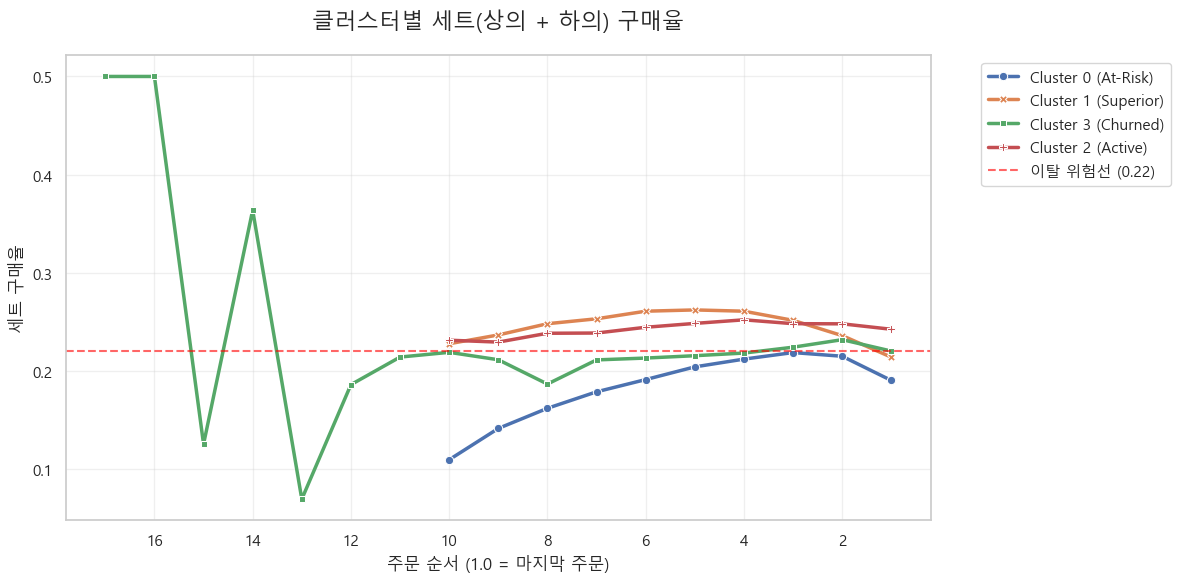

In [290]:
# 1. 데이터 합치기 (이미 계산된 각 클러스터의 trend 시리즈 활용)
# 주의: 앞에서 계산한 c0_trend, c1_trend, c2_trend, c3_trend를 사용합니다.
comparison_df = pd.DataFrame({
    'Cluster 0 (At-Risk)': c0_trend,
    'Cluster 1 (Superior)': c1_trend,
    'Cluster 3 (Churned)': set_purchase_trend, # 아까 만든 C3 데이터
    'Cluster 2 (Active)': c2_trend
})

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
sns.lineplot(data=comparison_df, markers=True, dashes=False, linewidth=2.5)

# 3. 그래프 꾸미기
plt.title('클러스터별 세트(상의 + 하의) 구매율', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('세트 구매율', fontsize=12)
plt.gca().invert_xaxis() # 1.0이 오른쪽 끝에 오도록 순서 뒤집기
plt.axhline(y=0.22, color='red', linestyle='--', alpha=0.6, label='이탈 위험선 (0.22)') # 위험선 표시
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 클러스터별 장바구니 갯수와 카테고리 종류 수

#### 클러스터별 평균 장바구니 갯수

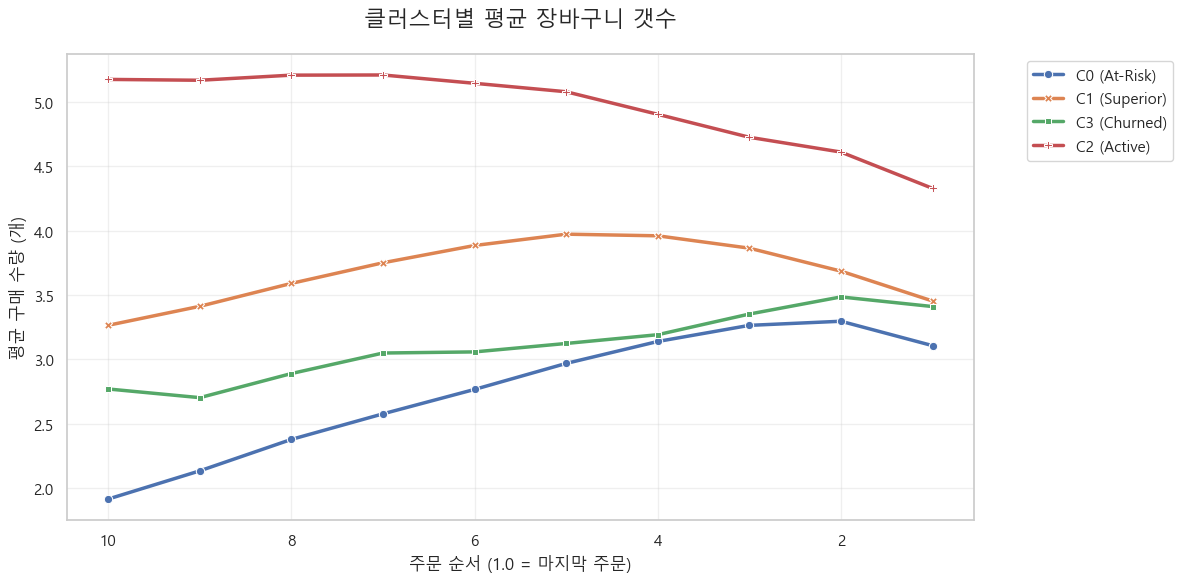

In [291]:
# 1. 각 클러스터별 평균 basket_size 트렌드 계산
# (이미 앞에서 생성한 c0_basket, c1_basket, c2_basket, c3_basket 활용)

size_comparison = pd.DataFrame({
    'C0 (At-Risk)': c0_basket[c0_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C1 (Superior)': c1_basket[c1_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C3 (Churned)': c3_basket[c3_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean(),
    'C2 (Active)': c2_basket[c2_basket['order_rank'] <= 10].groupby('order_rank')['basket_size'].mean()
})

# 2. 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=size_comparison, markers=True, dashes=False, linewidth=2.5)

plt.title('클러스터별 평균 장바구니 갯수', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('평균 구매 수량 (개)', fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 클러스터별 평균 카테고리 종류 수

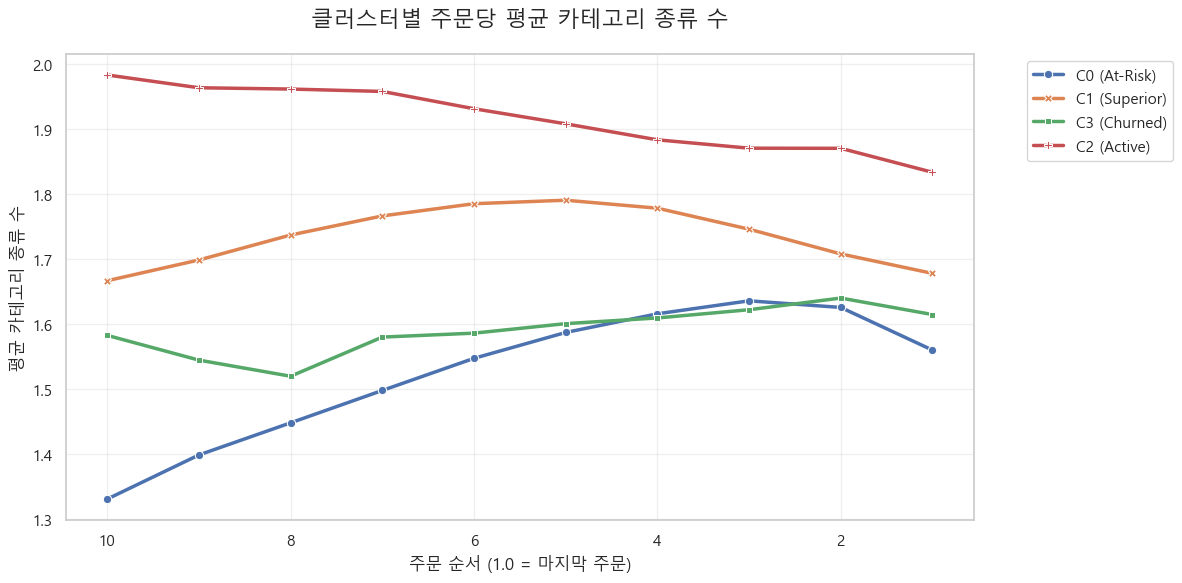

In [292]:
# 1. 각 클러스터별 카테고리 종류 수(Diversity) 계산 함수
def get_diversity_trend(df_cluster, basket_summary):
    # 주문별 유니크한 카테고리 개수 계산
    diversity = df_cluster.groupby(['customer_id', 't_dat'])['product_group_name'].nunique().reset_index(name='category_count')
    
    # 주문 순서(order_rank) 병합
    diversity = diversity.merge(basket_summary[['customer_id', 't_dat', 'order_rank']], on=['customer_id', 't_dat'])
    
    # 순서별 평균 계산
    return diversity.groupby('order_rank')['category_count'].mean()

# 2. 각 클러스터별 트렌드 산출
# (기존에 생성한 c0_basket, c1_basket, c2_basket, c3_basket 활용)
c0_div = get_diversity_trend(c0_df, c0_basket)
c1_div = get_diversity_trend(c1_df, c1_basket)
c2_div = get_diversity_trend(c2_df, c2_basket)
c3_div = get_diversity_trend(c3_df, c3_basket)

# 3. 데이터 합치기
div_comparison = pd.DataFrame({
    'C0 (At-Risk)': c0_div,
    'C1 (Superior)': c1_div,
    'C3 (Churned)': c3_div,
    'C2 (Active)': c2_div
})

# 4. 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=div_comparison[div_comparison.index <= 10], markers=True, dashes=False, linewidth=2.5)

plt.title('클러스터별 주문당 평균 카테고리 종류 수', fontsize=16, pad=20)
plt.xlabel('주문 순서 (1.0 = 마지막 주문)', fontsize=12)
plt.ylabel('평균 카테고리 종류 수', fontsize=12)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 그 밖에 분석들

#### Cluster0만 추출

In [280]:
# 1. 만약 고객 ID가 들어있는 데이터프레임 이름이 'user_df'나 'customers'라면 그걸 넣으세요.
# 만약 기억이 안 난다면, 클러스터링 직전에 사용했던 변수를 확인해보세요.

customer_clusters = pd.DataFrame({
    'customer_id': df['customer_id'].unique(), # 원본 df에서 중복 없는 고객 ID만 가져오기
    'cluster': kmeans.labels_
})

# 2. 이제 다시 합치기(Merge)
df_final = df.merge(customer_clusters, on='customer_id', how='inner')

# 3. Cluster 3만 필터링
c0_df = df_final[df_final['cluster'] == 0]

print(f"성공! Cluster 3 데이터 {len(c0_df)}건 추출 완료.")

성공! Cluster 3 데이터 10303945건 추출 완료.


#### LTV

--- Cluster 0 LTV 핵심 지표 ---
평균 총 구매액(M): 302.3445
평균 활동 기간: 171.3일
평균 구매 빈도(F): 18.2회
일일 기대 가치: 21.411505


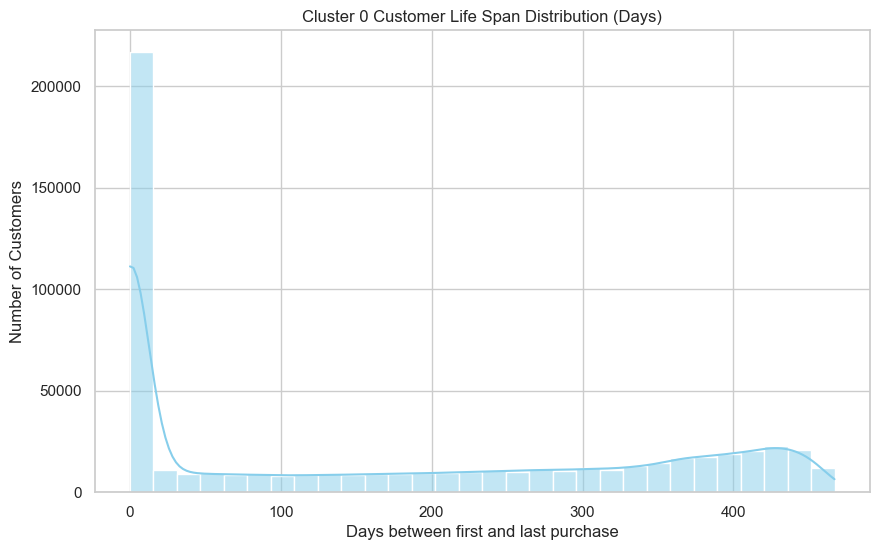

In [281]:
# 1. Cluster 0 데이터만 추출 (날짜 데이터를 날짜형식으로 변환)
c0_df = df_final[df_final['cluster'] == 0].copy()
c0_df['t_dat'] = pd.to_datetime(c0_df['t_dat'])

# 2. 고객별 LTV 관련 지표 계산
# 고객별로 [첫 구매일, 마지막 구매일, 총 구매금액, 총 구매횟수]를 구합니다.
ltv_base = c0_df.groupby('customer_id').agg({
    't_dat': ['min', 'max', 'count'],
    'price': 'sum'
}).reset_index()

# 컬럼 이름 정리
ltv_base.columns = ['customer_id', 'first_purchase', 'last_purchase', 'frequency', 'total_monetary']

# 3. 고객별 활동 기간(Life Span) 계산 (단위: 일)
ltv_base['life_span_days'] = (ltv_base['last_purchase'] - ltv_base['first_purchase']).dt.days

# 4. 활동 기간이 0일인 고객(단발성 구매)을 위해 최소 1일로 보정 후 일일 평균 매출 계산
ltv_base['daily_value'] = ltv_base['total_monetary'] / (ltv_base['life_span_days'] + 1)

# 5. Cluster 0 전체의 평균 지표 출력
print(f"--- Cluster 0 LTV 핵심 지표 ---")
print(f"평균 총 구매액(M): {ltv_base['total_monetary'].mean():.4f}")
print(f"평균 활동 기간: {ltv_base['life_span_days'].mean():.1f}일")
print(f"평균 구매 빈도(F): {ltv_base['frequency'].mean():.1f}회")
print(f"일일 기대 가치: {ltv_base['daily_value'].mean():.6f}")

# 6. 시각화 (활동 기간 분포)
plt.figure(figsize=(10, 6))
sns.histplot(ltv_base['life_span_days'], bins=30, kde=True, color='skyblue')
plt.title('Cluster 0 Customer Life Span Distribution (Days)')
plt.xlabel('Days between first and last purchase')
plt.ylabel('Number of Customers')
plt.show()

#### 연관 분석

In [282]:

from mlxtend.frequent_patterns import apriori, association_rules

# 1. 분석할 Cluster 0의 Top 10 카테고리 리스트 정의
target_categories = [
    'Jersey Fancy', 'Jersey Basic', 'Under-, Nightwear', 'Swimwear',
    'Trousers', 'Blouses', 'Knitwear', 'Dresses Ladies', 
    'Accessories', 'Trousers Denim'
]

# 2. 데이터 필터링 (에러 방지를 위해 df_final 사용)
# 'cluster' 컬럼이 있는 df_final에서 3번 클러스터만 먼저 추출합니다.
c0_df = df_final[df_final['cluster'] == 3]

# 그 중 우리가 정한 10개 카테고리에 속하는 데이터만 남깁니다.
c0_cat_only = c0_df[c0_df['garment_group_name'].isin(target_categories)].copy()

# 3. 장바구니 만들기 (pivot_table 방식이 더 안정적일 수 있습니다)
# 고객별+날짜별로 어떤 카테고리를 샀는지 10개의 열로 펼칩니다.
basket_cat = (c0_cat_only.groupby(['customer_id', 't_dat', 'garment_group_name'])['garment_group_name']
              .count().unstack().fillna(0))

# 4. 데이터 이진화 (구매 여부 0/1)
# 1개 이상 샀으면 1, 아니면 0으로 변환하여 연관분석 규격에 맞춥니다.
basket_sets_cat = basket_cat.map(lambda x: 1 if x > 0 else 0)

# 5. 연관분석 실행
# 카테고리 데이터는 조합이 흔하므로 min_support를 0.01(1%)로 설정합니다.
frequent_itemsets = apriori(basket_sets_cat, min_support=0.01, use_colnames=True)

# 6. 연관 규칙 생성 및 결과 확인
if not frequent_itemsets.empty:
    rules_cat = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    final_rules_cat = rules_cat.sort_values('lift', ascending=False)
    
    print("--- Cluster 0: Top 10 카테고리 간 연관성 분석 결과 ---")
    print(final_rules_cat[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))
else:
    print("조건을 만족하는 연관 규칙이 없습니다. min_support 값을 낮춰보세요.")

--- Cluster 0: Top 10 카테고리 간 연관성 분석 결과 ---
                                   antecedents  \
49                        frozenset({Blouses})   
44       frozenset({Trousers, Dresses Ladies})   
38   frozenset({Jersey Fancy, Dresses Ladies})   
43                        frozenset({Blouses})   
39          frozenset({Jersey Fancy, Blouses})   
42                 frozenset({Dresses Ladies})   
146  frozenset({Jersey Fancy, Trousers Denim})   
151                      frozenset({Trousers})   
150                frozenset({Trousers Denim})   
147        frozenset({Jersey Fancy, Trousers})   
68         frozenset({Jersey Fancy, Trousers})   
73                        frozenset({Blouses})   
121                  frozenset({Jersey Basic})   
116  frozenset({Jersey Fancy, Trousers Denim})   
51          frozenset({Jersey Basic, Blouses})   
54                   frozenset({Jersey Fancy})   
87   frozenset({Jersey Basic, Dresses Ladies})   
90                   frozenset({Jersey Fancy})   
45     

## 재고 최적화

In [283]:
# 1. 상품별 판매 지표 계산 (판매량, 판매 기간)
inventory_stats = df.groupby('article_id').agg({
    't_dat': ['count', 'min', 'max', 'nunique'], # 판매 건수, 첫 판매일, 마지막 판매일, 판매 일수
    'price': 'mean'                              # 평균 가격
}).reset_index()

# 컬럼명 정리
inventory_stats.columns = ['article_id', 'sales_count', 'first_sale', 'last_sale', 'sale_days', 'avg_price']

# 2. 판매 속도(Velocity) 지표 생성 
# 전체 운영 기간 중 얼마나 자주 팔렸는지 계산 (판매 건수 / 판매 일수)
inventory_stats['sales_velocity'] = inventory_stats['sales_count'] / inventory_stats['sale_days']

# 3. '악성 재고' 정의: 판매량 기준 하위 20% 추출
# (데이터의 신뢰도를 위해 최소 5일 이상 판매된 상품 중에서 고릅니다)
min_days_filter = inventory_stats['sale_days'] >= 5
low_performers = inventory_stats[min_days_filter].nsmallest(int(len(inventory_stats)*0.2), 'sales_count')

# 4. 최종 재고 리스트 저장
dead_stock_list = low_performers['article_id'].unique()
print(f"📦 분석 대상 악성 재고 선정 완료: {len(dead_stock_list):,}개 아이템")

📦 분석 대상 악성 재고 선정 완료: 15,819개 아이템


[Cluster 2(VIP) 취향 분석 결과]
--------------------------------------------------
1. VIP(C2) 선호 제품군(Top 5):
 product_group_name
Garment Upper body    0.414020
Garment Lower body    0.230858
Garment Full body     0.125346
Underwear             0.063273
Swimwear              0.059844
Name: proportion, dtype: float64

2. VIP(C2) 선호 색상(Top 5):
 perceived_colour_master_name
Black    0.352168
Blue     0.129746
White    0.126972
Beige    0.070041
Grey     0.062103
Name: proportion, dtype: float64
--------------------------------------------------


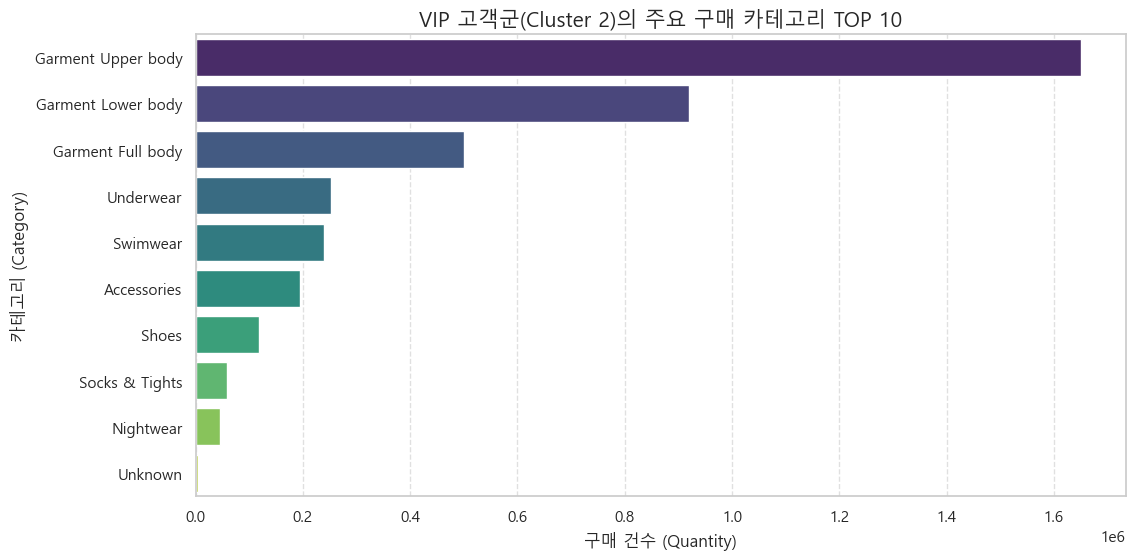

In [298]:
# 1. 새로운 클러스터 정의에 따른 VIP(Cluster 2) 데이터 필터링
# 재분류된 결과에 따라 Cluster 2인 고객 ID를 추출합니다.
vip_c2_ids = rfm[rfm['Cluster'] == 2]['customer_id']

# 전체 데이터(df)에서 새로운 VIP 고객의 구매 이력만 가져옵니다.
vip_c2_style = df[df['customer_id'].isin(vip_c2_ids)].copy()

# 2. 주요 속성별 비중 계산 함수 (재사용)
def get_top_styles(data, column_name):
    if column_name in data.columns:
        return data[column_name].value_counts(normalize=True).head(5)
    else:
        return f"⚠️ '{column_name}' 컬럼을 찾을 수 없습니다."

print("[Cluster 2(VIP) 취향 분석 결과]")
print("-" * 50)
print("1. VIP(C2) 선호 제품군(Top 5):\n", get_top_styles(vip_c2_style, 'product_group_name'))
print("\n2. VIP(C2) 선호 색상(Top 5):\n", get_top_styles(vip_c2_style, 'perceived_colour_master_name'))
print("-" * 50)

# 3. 시각화: VIP(C2)의 카테고리별 구매 비중
plt.figure(figsize=(12, 6))

# 'product_group_name' 컬럼 기준으로 상위 10개 추출
top_10_categories = vip_c2_style['product_group_name'].value_counts().index[:10]

# VIP의 품격에 어울리는 'viridis' 혹은 'gold' 톤의 팔레트를 추천합니다.
sns.countplot(data=vip_c2_style, y='product_group_name', 
              order=top_10_categories,
              palette='viridis')

plt.title('VIP 고객군(Cluster 2)의 주요 구매 카테고리 TOP 10', fontsize=15)
plt.xlabel('구매 건수 (Quantity)')
plt.ylabel('카테고리 (Category)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()